# DP multi-component workflow (test)

Mirrors `dp_workflow.ipynb` but drives the refactored `src/DP_new.py`.
Key API changes vs. the old two-component `DP`:

- `fit_all` returns **`(dp_parent, dp_components, model_cube)`** instead of L/R arrays.
- `dp_parent`: one scalar row per galaxy (Z, mass, chosen `N_COMP`, BIC/chi2 per N, total flux per line).
- `dp_components`: **tidy/long** table, one row per (target, component, line).
- `bpt_classification` / `estimate_SFR` / `select_dp_sample` consume `dp_components`.
- `plot_fit` overlays every component for a target.

In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP_new import DP
import matplotlib.pyplot as plt
import numpy as np

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [3]:
# new-schema output catalogs (parent + components + model cube live in one FITS each)
filenames = {
    'all' : './catalogs/test_all_multicomp_0901_test.fits',
    'dps' : './catalogs/test_dps_multicomp_0901_test.fits',
}

## Build the sample: keep sources with >=1 significant emission line (>5 S/N)

In [4]:
FIT = FitSpectrum()
DP  = DP()

ALL_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=None, subtype_filter='QSO')
print('Total number of spectra:', len(ALL_SPECTRA.targetID))

Data loading and processing took 47.37 seconds.
Total number of spectra: 99812


In [5]:
ALL_SPECTRA = FIT.label_emission_lines(ALL_SPECTRA, 5)
ALL_SPECTRA = FIT.significant_emission_filter(ALL_SPECTRA)
print('After significant-emission filter:', len(ALL_SPECTRA.targetID))

After significant-emission filter: 57271


In [6]:
# --- TEST MODE: thin the sample so a full 1..4-component fit runs quickly ---
# Comment this out for a production run.
ALL_SPECTRA = ALL_SPECTRA.shrink_dataset(10)
print('After shrinking:', len(ALL_SPECTRA.targetID))

After shrinking: 5728


In [7]:
ALL_SPECTRA.df.head()

,TARGETID,RA,DEC,Z,SPECTYPE,LOGM,LOGSFR,OII,Hbeta,OIII,Halpha,NII,SII
0,39627739380056197,177.003822,-1.903397,0.224113,GALAXY,10.250155,-0.348563,False,False,False,True,False,False
1,39627739380058181,177.086335,-1.944353,0.104128,GALAXY,9.806542,0.324603,False,True,False,True,True,True
2,39627739384252668,177.344846,-1.979829,0.115064,GALAXY,9.450577,0.099876,True,True,False,True,False,True
3,39627739388450085,177.708902,-1.988507,0.174826,GALAXY,10.169886,0.802034,True,True,True,True,True,True
4,39627739392644554,177.974945,-1.998510,0.242007,GALAXY,10.127140,-0.275864,False,False,False,True,False,False


## Fit everything
For each target, `fit_dp` fits N = 1..4 velocity components, picks N by minimum BIC,
and emits a scalar parent row + tidy per-(component, line) rows + the best-fit model.

In [8]:
dp_parent, dp_components, model_cube = DP.fit_all(data_class=ALL_SPECTRA, n_jobs=10)
print('parent    :', dp_parent.shape)
print('components:', dp_components.shape)
print('model cube:', model_cube.shape)
print('N_COMP distribution:')
print(dp_parent['N_COMP'].value_counts().sort_index())

100%|██████████| 5728/5728 [02:33<00:00, 37.27it/s]


parent    : (5728, 26)
components: (75550, 14)
model cube: (5728, 7781)
N_COMP distribution:
N_COMP
1    4097
2    1449
3     168
4      14
Name: count, dtype: int64


In [9]:
dp_parent[dp_parent['N_COMP']==1].head()

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,N_COMP,N_COMP_FIT,BIC_1,CHISQ_1,...,OII3726_FLUX_TOT,OII3729_FLUX_TOT,Hbeta_FLUX_TOT,OIII4959_FLUX_TOT,OIII5007_FLUX_TOT,NII6548_FLUX_TOT,NII6583_FLUX_TOT,Halpha_FLUX_TOT,SII6716_FLUX_TOT,SII6731_FLUX_TOT
0,39627739380056197,177.003815,-1.903397,0.224113,10.250154,-0.348563,1,1,807.014282,746.630554,...,2.234996,2.974765,2.358496,0.383114,1.160451,1.938171,5.943389,14.052762,1.258454,2.053484
1,39627739380058181,177.086334,-1.944353,0.104128,9.806542,0.324603,1,1,848.851379,789.355103,...,12.605669,16.778061,33.974606,1.427988,4.325373,19.046337,58.405468,147.653656,22.587009,18.107811
2,39627739384252668,177.344849,-1.979829,0.115064,9.450577,0.099876,1,1,759.204041,699.635376,...,4.207742,5.600476,3.590678,0.882238,2.672297,1.175812,3.605621,16.677942,5.344600,3.125769
4,39627739392644554,177.974945,-1.998510,0.242007,10.127140,-0.275864,1,1,994.081421,933.502258,...,4.914390,6.541020,7.699676,0.642739,1.946854,3.553669,10.897303,24.916504,8.146760,8.802567
5,39627739396836975,178.161896,-1.962002,0.085308,10.490271,-3.019501,1,1,777.236572,717.899170,...,14.882112,19.807991,17.532875,5.048345,15.291421,11.116142,34.087578,56.949314,17.200884,6.464499


## Persist to FITS and round-trip

In [10]:
DP.get_catalog(dp_parent, dp_components, model_cube, fname=filenames['all'])


In [11]:

dp_parent, dp_components, model_cube = DP.extract_fits_data(filenames['all'])
print('reloaded:', dp_parent.shape, dp_components.shape, model_cube.shape)

reloaded: (5728, 26) (75550, 14) (5728, 7781)


## Per-component science: BPT and SFR
Both now return one result **per component** instead of a fixed L/R pair.

In [12]:
bpt = DP.bpt_classification(dp_components)
# attach the class back onto the component rows
dp_components = dp_components.merge(bpt, on=['TARGETID', 'COMP_IDX'], how='left')
bpt.head(10)

/Users/hyp0515/master_project/code/main/nature_of_DP/src/DP_new.py:603: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(classify)


,TARGETID,COMP_IDX,BPT,OIII_HB_BOUND,NII_HA_BOUND
0,39627739380056197,0,1,uncertain,upper_limit
1,39627739380058181,0,1,upper_limit,measured
2,39627739384252668,0,1,measured,measured
3,39627739388450085,0,4,measured,measured
4,39627739388450085,1,1,measured,measured
5,39627739392644554,0,1,uncertain,measured
6,39627739396836975,0,4,measured,measured
7,39627739401028867,0,16,uncertain,upper_limit
8,39627739401028867,1,4,uncertain,measured
9,39627739401031713,0,1,uncertain,measured


In [13]:
per_comp_sfr, dp_parent = DP.estimate_SFR(dp_components, dp_parent)
print('total SFR written to parent as LOGSFR_FIT')
per_comp_sfr.head()

/Users/hyp0515/master_project/code/main/nature_of_DP/src/misc.py:235: RuntimeWarning: overflow encountered in scalar power
  flux_intrinsic = flux_halpha / (10**(A_halpha/-2.5)) * 1e-17


total SFR written to parent as LOGSFR_FIT


/Users/hyp0515/master_project/code/main/nature_of_DP/src/DP_new.py:1094: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(comp_sfr)


,TARGETID,COMP_IDX,SFR,LOGSFR
0,39627739380056197,0,0.737449,-0.132268
1,39627739380058181,0,0.793929,-0.100219
2,39627739384252668,0,0.133561,-0.874319
3,39627739388450085,0,2.137373,0.329880
4,39627739388450085,1,0.848086,-0.071560


## Select the multi-component (DP+) sample
A galaxy qualifies when its best model has >1 component AND >=2 components are
significantly detected (`SIG`) in the same line.

In [14]:
dp_sample = DP.select_dp_sample(dp_parent, dp_components)
print('DP+ candidates:', len(dp_sample), '/', len(dp_parent))
# save the DP+ subset (parent rows + their component rows + their model slices)
mask = dp_parent['TARGETID'].isin(dp_sample['TARGETID'])
DP.get_catalog(dp_sample,
               dp_components[dp_components['TARGETID'].isin(dp_sample['TARGETID'])],
               model_cube[mask.to_numpy()],
               fname=filenames['dps'])
# dp_sample.sort_values('N_COMP_FIT', ascending=True).head(50)
dp_sample[dp_sample['N_COMP_FIT'] == 4].head(50)

DP+ candidates: 1601 / 5728


,TARGETID,RA,DEC,Z,LOGM,LOGSFR,N_COMP,N_COMP_FIT,BIC_1,CHISQ_1,...,OII3729_FLUX_TOT,Hbeta_FLUX_TOT,OIII4959_FLUX_TOT,OIII5007_FLUX_TOT,NII6548_FLUX_TOT,NII6583_FLUX_TOT,Halpha_FLUX_TOT,SII6716_FLUX_TOT,SII6731_FLUX_TOT,LOGSFR_FIT
411,39627745818317047,200.956894,-1.759034,0.223888,10.505062,-5.230967,4,4,1070.584961,1010.157471,...,56.272003,28.437342,46.538628,140.965363,21.620071,66.297806,87.373199,42.521946,32.063911,-0.017571
984,39627752202045152,221.315399,-1.595362,0.318765,10.545135,0.901063,4,4,1553.315430,1492.204590,...,87.715271,76.829987,290.603638,880.237549,37.619526,115.360023,276.946564,57.959797,43.335815,1.636711
1058,39627757579144853,181.933655,-1.289800,0.178936,10.097242,1.603496,4,4,2004.614502,1944.532104,...,53.420353,81.874016,12.538733,37.979786,54.743618,167.870941,379.745331,60.256145,39.107277,0.952621
1423,39627758296372508,224.711273,-1.320670,0.037854,10.273092,0.955742,4,4,5882.479980,5823.494629,...,141.329437,202.255630,26.083052,79.005486,224.818069,689.403137,1207.621826,248.500092,186.573410,0.501070
1671,39627763992232008,204.001480,-1.032605,0.175921,9.320223,1.669138,4,4,3417.260498,3357.155518,...,118.695976,140.837570,35.004730,106.029221,88.092667,270.135590,680.078369,103.001045,87.052910,1.380829
3299,39627788042373744,197.633270,0.036640,0.178932,9.739586,2.057347,4,4,2775.016357,2714.979248,...,341.471802,393.829803,196.531952,595.294739,153.822586,471.695953,1638.321167,168.977554,138.863556,1.460290
3697,39627794073784764,197.187149,0.193738,0.083686,10.259756,0.914023,4,4,1763.146240,1703.784180,...,79.059608,80.264771,41.419247,125.458778,104.757439,321.237976,374.269897,79.184952,68.236237,0.642037
3744,39627794161862207,202.321075,0.249177,0.376161,10.182315,2.083117,4,4,4403.735840,4342.296875,...,51.500618,54.773483,23.735521,71.894821,27.426138,84.102074,257.127777,37.712704,25.984987,1.581665
4525,39627806245654123,202.652969,0.766224,0.364264,10.810341,1.809644,4,4,1778.754883,1717.453613,...,47.989498,51.749050,9.139925,27.684807,32.159363,98.616478,262.942902,47.208942,31.856504,1.851939
5055,39627812520335199,216.728577,0.996150,0.383232,10.538985,1.799457,4,4,3420.203125,3358.676758,...,26.728544,40.701225,89.798050,271.998047,52.258846,160.251404,191.527786,28.819441,27.277788,1.465584


In [15]:
dp_components[(dp_components['N_COMP']==2)
              & (dp_components['SIGMA']>60)
              & (dp_components['LINE']=='Halpha')
              & (dp_components['SIG']==True)
              & (dp_components['BPT']==16) 
              & (dp_components['OIII_HB_BOUND'] == 'measured')
              & (dp_components['NII_HA_BOUND'] == 'measured')
              & (np.abs(dp_components['DV'])<80)
              ].sort_values('SIGMA', ascending=True).head(50)

,TARGETID,N_COMP,COMP_IDX,LINE,LAM0,DV,SIGMA,AMP,FLUX,FLUX_ERR,SNR,SIG,NOISE3,COMP_INSIG,BPT,OIII_HB_BOUND,NII_HA_BOUND
6247,39627745898008834,2,1,Halpha,6564.631836,0.160502,64.131821,19.634678,69.115776,1.940058,21.952929,True,9.445087,False,16,measured,measured
71877,39627818534962803,2,1,Halpha,6564.631836,2.200105,84.790848,16.729362,77.859421,2.871150,15.099306,True,15.469470,False,16,measured,measured
27997,39627770120116121,2,0,Halpha,6564.631836,-8.702002,104.777451,17.395412,100.039047,12.759253,14.538658,True,20.642700,False,16,measured,measured
37047,39627781834804985,2,1,Halpha,6564.631836,5.832837,109.793053,8.521441,51.354198,2.353987,12.325610,True,12.499390,False,16,measured,measured
67607,39627817914204301,2,1,Halpha,6564.631836,11.141718,115.413322,14.458369,91.594841,2.330721,31.277599,True,8.785346,False,16,measured,measured
65797,39627812398698172,2,1,Halpha,6564.631836,56.042999,120.325218,6.419240,42.403435,4.047372,9.122172,True,13.945177,False,16,measured,measured
23657,39627764248085823,2,0,Halpha,6564.631836,-3.023172,123.119392,24.930540,168.474197,3.443412,25.388412,True,19.907610,False,16,measured,measured
2807,39627745445019694,2,0,Halpha,6564.631836,-34.395519,139.365982,8.341762,63.803474,1.649929,14.777833,True,12.952537,False,16,measured,measured
3417,39627745516327965,2,1,Halpha,6564.631836,56.749722,139.818283,13.162946,101.036636,6.731024,19.331274,True,15.679769,False,16,measured,measured
52797,39627799933224514,2,0,Halpha,6564.631836,-20.095715,149.580017,7.936808,65.158333,5.153764,11.247197,True,17.379885,False,16,measured,measured


In [16]:
line = 'Halpha'

sub = dp_components[
    (dp_components['TARGETID'].isin(dp_sample[dp_sample['N_COMP_FIT'] == 4]['TARGETID']))
    & ((dp_components['LINE'] == 'Halpha') & (dp_components['SIG'] == True))
    # & ((dp_components['LINE'] == 'OIII5007') & (dp_components['SIG'] == True))
    # & (dp_components['BPT'] == 16)
    # & (np.abs(dp_components['DV']) > 90)
    & (dp_components['OIII_HB_BOUND'] != 'uncertain')
    & (dp_components['NII_HA_BOUND'] != 'uncertain')
    # & (dp_components['OIII_HB_BOUND'] == 'measured')
    # & (dp_components['NII_HA_BOUND'] == 'measured')
]


sub_oiii = dp_components[
    (dp_components['TARGETID'].isin(dp_sample[dp_sample['N_COMP_FIT'] == 4]['TARGETID']))
    & ((dp_components['LINE'] == 'OIII5007') & (dp_components['SIG'] == True))
    # & ((dp_components['LINE'] == 'OIII5007') & (dp_components['SIG'] == True))
    # & (dp_components['BPT'] == 16)
    # & (np.abs(dp_components['DV']) > 90)
    # & (dp_components['OIII_HB_BOUND'] != 'uncertain')
    # & (dp_components['NII_HA_BOUND'] != 'uncertain')
    # & (dp_components['OIII_HB_BOUND'] == 'measured')
    # & (dp_components['NII_HA_BOUND'] == 'measured')
]


dv_ = sub.pivot(index='TARGETID', columns='COMP_IDX', values='DV')
sigma_ = sub.pivot(index='TARGETID', columns='COMP_IDX', values='SIGMA')
amp_ = sub.pivot(index='TARGETID', columns='COMP_IDX', values='AMP')


dv_oiii_ = sub_oiii.pivot(index='TARGETID', columns='COMP_IDX', values='DV')
sigma_oiii_ = sub_oiii.pivot(index='TARGETID', columns='COMP_IDX', values='SIGMA')
amp_oiii_ = sub_oiii.pivot(index='TARGETID', columns='COMP_IDX', values='AMP')


In [17]:
dv_oiii_[(sigma_oiii_[0]*sigma_oiii_[1]*sigma_oiii_[2]*sigma_oiii_[3]>0)].head(50)

COMP_IDX,0,1,2,3
TARGETID,,,,
39627745818317047,-279.554962,-90.637444,55.221928,106.106934
39627752202045152,-144.434921,-134.691147,-2.970584,119.305710
39627763992232008,-102.837990,-12.780535,-11.903812,59.194828
39627788042373744,-55.313881,-6.298645,56.382668,75.451866
39627812520335199,-81.163422,-0.198194,5.032100,9.997666
39627818186837174,-195.183716,-49.942829,-0.866206,112.807999
39627818543350738,-193.778915,-109.262489,5.631815,236.578262
39627824386017242,-305.369019,-148.570831,1.831050,172.804062


In [18]:
len(dv_oiii_[(sigma_oiii_[0]*sigma_oiii_[1]*sigma_oiii_[2]*sigma_oiii_[3]>0)])

8

In [19]:
dv_[(sigma_[0]*sigma_[1]*sigma_[2]*sigma_[3]>0)].head(50)

COMP_IDX,0,1,2,3
TARGETID,,,,
39627758296372508,-95.065407,-66.723732,58.130825,100.999649
39627763992232008,-102.837990,-12.780535,-11.903812,59.194828
39627788042373744,-55.313881,-6.298645,56.382668,75.451866
39627794161862207,-148.689835,-32.924854,156.354797,223.495209
39627812520335199,-81.163422,-0.198194,5.032100,9.997666
39627817956148534,-139.134842,-94.678833,4.493295,101.230629
39627818186837174,-195.183716,-49.942829,-0.866206,112.807999
39627824386017242,-305.369019,-148.570831,1.831050,172.804062


In [20]:
len(dv_[(sigma_[0]*sigma_[1]*sigma_[2]*sigma_[3]>0)])

8

In [21]:
dv_['STD'] = dv_.std(axis=1)
dv_['MAX'] = dv_.max(axis=1)
dv_['MIN'] = dv_.min(axis=1)
dv_['DIFF'] = dv_['MAX'] - dv_['MIN']
dv_['MEAN'] = dv_.mean(axis=1)

dv_['SIG_STD'] = sigma_.std(axis=1)
dv_['SIG_MAX'] = sigma_.max(axis=1)
dv_['SIG_MIN'] = sigma_.min(axis=1)
dv_['SIG_DIFF'] = dv_['SIG_MAX'] - dv_['SIG_MIN']
dv_['SIG_MEAN'] = sigma_.mean(axis=1)

dv_['TARGETID'] = dv_.index
dv_[(sigma_[0]*sigma_[1]*sigma_[2]*sigma_[3]>0) & (dv_['DIFF']>200)].sort_values('SIG_MIN', ascending=True).head(50)

COMP_IDX,0,1,2,3,STD,MAX,MIN,DIFF,MEAN,SIG_STD,SIG_MAX,SIG_MIN,SIG_DIFF,SIG_MEAN,TARGETID
TARGETID,,,,,,,,,,,,,,,
39627794161862207,-148.689835,-32.924854,156.354797,223.495209,171.041245,223.495209,-148.689835,372.185059,102.033371,71.629547,180.973755,29.779741,151.194016,73.909317,39627794161862207
39627817956148534,-139.134842,-94.678833,4.493295,101.230629,107.220444,107.220444,-139.134842,246.355286,24.196445,168.344833,382.043701,41.565266,340.478424,129.559708,39627817956148534
39627818186837174,-195.183716,-49.942829,-0.866206,112.807999,127.649025,127.649025,-195.183716,322.832733,31.220291,178.283356,448.739929,72.189049,376.550873,186.078873,39627818186837174
39627824386017242,-305.369019,-148.570831,1.831050,172.804062,204.682953,204.682953,-305.369019,510.051971,41.843010,132.155396,373.053436,82.404350,290.649078,177.398651,39627824386017242


In [22]:
print(dv_['TARGETID'])

TARGETID
39627745818317047    39627745818317047
39627752202045152    39627752202045152
39627757579144853    39627757579144853
39627758296372508    39627758296372508
39627763992232008    39627763992232008
39627788042373744    39627788042373744
39627794073784764    39627794073784764
39627794161862207    39627794161862207
39627806245654123    39627806245654123
39627812520335199    39627812520335199
39627817956148534    39627817956148534
39627818186837174    39627818186837174
39627818543350738    39627818543350738
39627824386017242    39627824386017242
Name: TARGETID, dtype: int64


In [23]:
DP.record_ids(dv_[(sigma_[0]*sigma_[1]*sigma_[2]*sigma_[3]>0) & (dv_['DIFF']>200)], fname='4_comp.csv')

In [24]:
sigma_

COMP_IDX,0,1,2,3
TARGETID,,,,
39627745818317047,NaN,29.003071,213.528305,11.905751
39627752202045152,104.493126,NaN,265.612152,79.835098
39627757579144853,56.129955,NaN,38.775612,41.533115
39627758296372508,40.106644,164.812775,62.613342,18.831558
39627763992232008,237.146805,92.028214,32.296303,23.220808
39627788042373744,61.812130,147.155472,327.145569,54.545467
39627794073784764,NaN,278.733612,64.161407,39.743706
39627794161862207,41.502895,180.973755,43.380848,29.779741
39627806245654123,NaN,70.752792,70.965546,16.373363


In [25]:
sigma_['STD'] = sigma_.std(axis=1)
sigma_['MAX'] = sigma_.max(axis=1)
sigma_['MIN'] = sigma_.min(axis=1)
sigma_['DIFF'] = sigma_['MAX'] - sigma_['MIN']
sigma_['MEAN'] = sigma_.mean(axis=1)
sigma_[(sigma_[0]*sigma_[1]*sigma_[2]*sigma_[3]>0)].head(50)

COMP_IDX,0,1,2,3,STD,MAX,MIN,DIFF,MEAN
TARGETID,,,,,,,,,
39627758296372508,40.106644,164.812775,62.613342,18.831558,64.667664,164.812775,18.831558,145.981216,85.082191
39627763992232008,237.146805,92.028214,32.296303,23.220808,98.814720,237.146805,23.220808,213.925995,119.725060
39627788042373744,61.812130,147.155472,327.145569,54.545467,126.827301,327.145569,54.545467,272.600098,171.472137
39627794161862207,41.502895,180.973755,43.380848,29.779741,71.629547,180.973755,29.779741,151.194016,91.151787
39627812520335199,12.966729,551.845154,85.794830,226.609131,238.772385,551.845154,12.966729,538.878418,277.459808
39627817956148534,382.043701,41.565266,46.888847,47.741016,168.344833,382.043701,41.565266,340.478424,181.333893
39627818186837174,77.585335,72.189049,448.739929,145.801193,178.283356,448.739929,72.189049,376.550873,227.509842
39627824386017242,373.053436,130.544907,82.404350,123.591949,132.155396,373.053436,82.404350,290.649078,198.482117


In [26]:
amp_

COMP_IDX,0,1,2,3
TARGETID,,,,
39627745818317047,NaN,3.402868,5.884441,4.399951
39627752202045152,6.104283,NaN,10.907039,5.797524
39627757579144853,36.030170,NaN,20.565954,64.004539
39627758296372508,147.328491,28.680691,133.706650,158.995361
39627763992232008,7.532460,53.984341,143.690659,42.891827
39627788042373744,108.625214,97.099525,10.670854,98.153297
39627794073784764,NaN,2.947068,56.580528,36.141930
39627794161862207,28.093348,15.371283,13.350235,5.310035
39627806245654123,NaN,18.558275,32.374680,9.455243


In [27]:
sigma_[((sigma_[0]/sigma_[1]<1.5)&(sigma_[0]>60)) | ((sigma_[1]/sigma_[0]<1.5)&(sigma_[1]>60))].head(50)

COMP_IDX,0,1,2,3,STD,MAX,MIN,DIFF,MEAN
TARGETID,,,,,,,,,
39627763992232008,237.146805,92.028214,32.296303,23.220808,98.814720,237.146805,23.220808,213.925995,119.725060
39627788042373744,61.812130,147.155472,327.145569,54.545467,126.827301,327.145569,54.545467,272.600098,171.472137
39627818186837174,77.585335,72.189049,448.739929,145.801193,178.283356,448.739929,72.189049,376.550873,227.509842
39627818543350738,73.814743,511.387817,NaN,NaN,309.410889,511.387817,73.814743,437.573059,319.564850
39627824386017242,373.053436,130.544907,82.404350,123.591949,132.155396,373.053436,82.404350,290.649078,198.482117


In [28]:
dp_components[(dp_components['TARGETID']==39627769713264939) & (dp_components['LINE']=='Halpha')]

,TARGETID,N_COMP,COMP_IDX,LINE,LAM0,DV,SIGMA,AMP,FLUX,FLUX_ERR,SNR,SIG,NOISE3,COMP_INSIG,BPT,OIII_HB_BOUND,NII_HA_BOUND
25157,39627769713264939,3,0,Halpha,6564.631836,-329.575073,341.732941,0.544115,10.194827,4.408868,0.390956,False,78.230049,True,4,uncertain,uncertain
25167,39627769713264939,3,1,Halpha,6564.631836,-11.130494,154.649384,3.400912,28.867359,4.987997,2.443610,False,35.440228,False,4,lower_limit,uncertain
25177,39627769713264939,3,2,Halpha,6564.631836,-0.326471,42.238602,28.592033,66.287811,1.891829,20.543833,True,9.679958,False,1,measured,measured


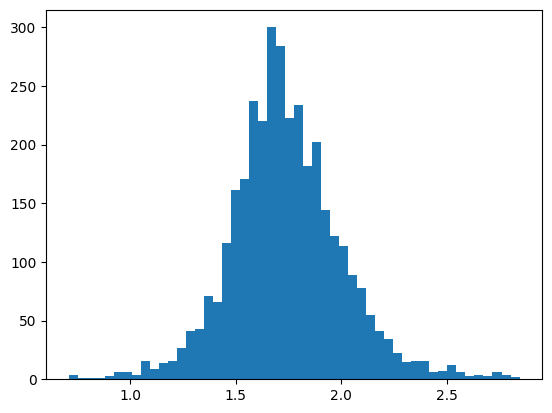

In [29]:
plt.hist(np.log10(dp_components[dp_components['N_COMP']!=1]['SIGMA'].unique()), bins=50)

plt.show()

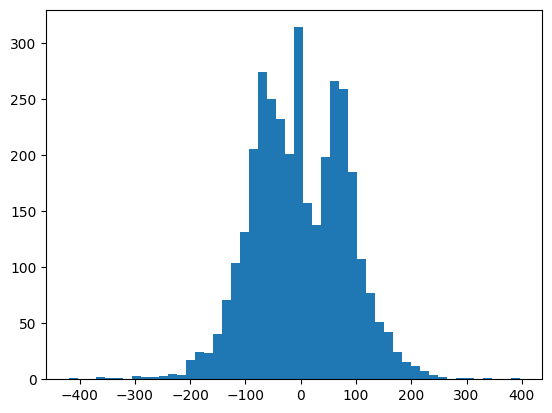

In [30]:
plt.hist((dp_components[dp_components['N_COMP']!=1]['DV'].unique()), bins=50)

plt.show()

## Eyeball a fit
Overlay data, total model, and every component for one target.

plotting TARGETID 39627812520335199  N_COMP = 4


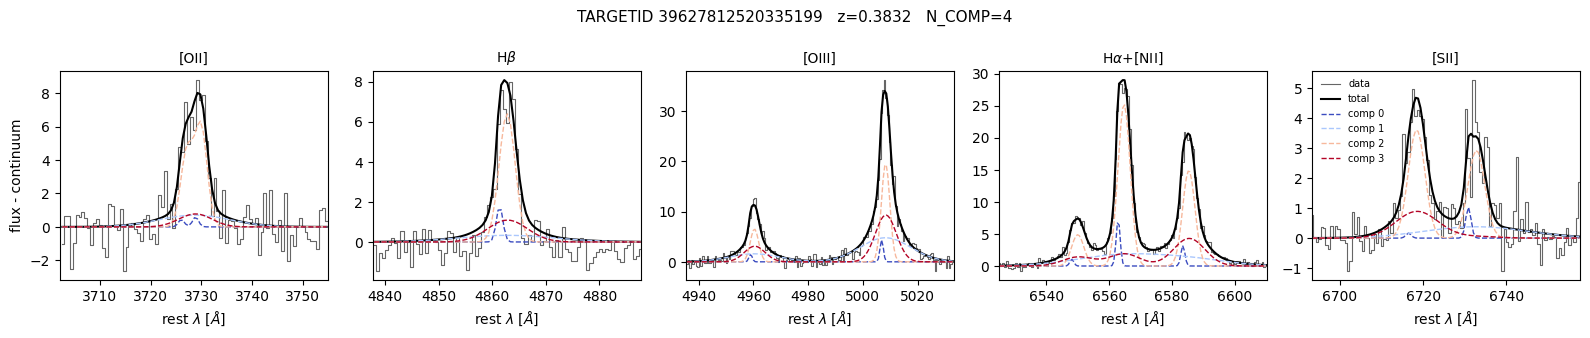

In [31]:
# prefer a multi-component target if we found one
if len(dp_sample):
    tid = int(dp_sample.sort_values('N_COMP', ascending=False)['TARGETID'].iloc[1])
else:
    tid = int(dp_parent['TARGETID'].iloc[0])
# tid = 39627793775986614
print('plotting TARGETID', tid, ' N_COMP =', int(dp_parent.loc[dp_parent['TARGETID']==tid, 'N_COMP'].iloc[0]))
fig, axes = DP.plot_fit(ALL_SPECTRA, dp_parent, dp_components, id=tid)
plt.show()

## Inspect the schema

In [32]:
print('parent columns:')
print(list(dp_parent.columns))
print()
print('component columns:')
print(list(dp_components.columns))

parent columns:
['TARGETID', 'RA', 'DEC', 'Z', 'LOGM', 'LOGSFR', 'N_COMP', 'N_COMP_FIT', 'BIC_1', 'CHISQ_1', 'BIC_2', 'CHISQ_2', 'BIC_3', 'CHISQ_3', 'BIC_4', 'CHISQ_4', 'OII3726_FLUX_TOT', 'OII3729_FLUX_TOT', 'Hbeta_FLUX_TOT', 'OIII4959_FLUX_TOT', 'OIII5007_FLUX_TOT', 'NII6548_FLUX_TOT', 'NII6583_FLUX_TOT', 'Halpha_FLUX_TOT', 'SII6716_FLUX_TOT', 'SII6731_FLUX_TOT', 'LOGSFR_FIT']

component columns:
['TARGETID', 'N_COMP', 'COMP_IDX', 'LINE', 'LAM0', 'DV', 'SIGMA', 'AMP', 'FLUX', 'FLUX_ERR', 'SNR', 'SIG', 'NOISE3', 'COMP_INSIG', 'BPT', 'OIII_HB_BOUND', 'NII_HA_BOUND']
